In [1]:
from pathlib import Path

import pandas as pd

base_dir = Path.cwd() / "Data"
file_100_200_300 = base_dir / "Veg_Resultater_100-200-300.xlsx"
file_400_500 = base_dir / "Veg_Resultater_400-500.xlsx"

veg_100_200_300_df = pd.read_excel(file_100_200_300, sheet_name="100-200-300")
veg_400_500_df = pd.read_excel(file_400_500, sheet_name="400-500")

veg_combined_df = pd.concat([veg_100_200_300_df, veg_400_500_df], axis=0, ignore_index=True)

print(f"100-200-300 rows: {veg_100_200_300_df.shape[0]}")
print(f"400-500 rows: {veg_400_500_df.shape[0]}")
print(f"Combined rows: {veg_combined_df.shape[0]}")
veg_combined_df.head()

sample_col = next(c for c in veg_combined_df.columns if "prøve" in str(c).lower() or "prove" in str(c).lower())
target_id = "V401"

src_100_200_300 = veg_100_200_300_df[veg_100_200_300_df[sample_col].astype(str).str.strip() == target_id]
src_400_500 = veg_400_500_df[veg_400_500_df[sample_col].astype(str).str.strip() == target_id]
combined_hit = veg_combined_df[veg_combined_df[sample_col].astype(str).str.strip() == target_id]

print(f"Sample column used: {sample_col}")
print(f"Rows in 100-200-300 for {target_id}: {len(src_100_200_300)}")
print(f"Rows in 400-500 for {target_id}: {len(src_400_500)}")
print(f"Rows in combined for {target_id}: {len(combined_hit)}")

print("\nMatch from 400-500 source:")
display(src_400_500.head())

print("\nMatch from combined dataframe:")
display(combined_hit.head())


100-200-300 rows: 143
400-500 rows: 33
Combined rows: 176
Sample column used: Prøve ID
Rows in 100-200-300 for V401: 0
Rows in 400-500 for V401: 1
Rows in combined for V401: 1

Match from 400-500 source:


,Prøve ID,Type prøve,total VEKT (g),Antall dekkpartikler,konsentrasjon (partikler/g),"konsentrasjon (punktsnitt, partikler/g)",Fartsgrense,Trafikkmengde (ÅDT)
0,V401,Gjerde,0.018,136.0,7555.555556,NaN,60.0,7600.0



Match from combined dataframe:


,Prøve ID,Type prøve,total VEKT (g),Antall dekkpartikler,konsentrasjon (partikler/m^2),"konsentrasjon (punktsnitt, partikler/m^2)",Fartsgrense,Trafikkmengde (ÅDT),avstand til vei (cm),Gj.snitt tall,Unnamed: 10,Unnamed: 11,konsentrasjon (partikler/g),"konsentrasjon (punktsnitt, partikler/g)"
143,V401,Gjerde,0.018,136.0,NaN,NaN,60.0,7600.0,NaN,NaN,NaN,NaN,7555.555556,NaN


In [2]:
veg_0_df = pd.read_csv(base_dir / "Veg_0.csv")

# Build numeric join key from Prøve ID in the combined Excel dataframe (e.g., V401 -> 401).
veg_combined_df = veg_combined_df.copy()
veg_combined_df["prove_id_numeric"] = pd.to_numeric(
    veg_combined_df["Prøve ID"].astype(str).str.extract(r"(\d+)", expand=False),
    errors="coerce",
)

# Ensure Veg_0 join key is numeric and deduplicate so merge does not create extra rows.
veg_0_df = veg_0_df.copy()
veg_0_df["Prøve_ID"] = pd.to_numeric(veg_0_df["Prøve_ID"], errors="coerce")
veg_0_dupe_ids = veg_0_df.loc[veg_0_df["Prøve_ID"].duplicated(keep=False), "Prøve_ID"].dropna().unique()
veg_0_unique_df = veg_0_df.drop_duplicates(subset=["Prøve_ID"], keep="first")

# Keep every row from veg_combined_df and append Veg_0 columns on the right.
veg_enriched_df = veg_combined_df.merge(
    veg_0_unique_df,
    left_on="prove_id_numeric",
    right_on="Prøve_ID",
    how="left",
    suffixes=("", "_veg0"),
)

print(f"Combined shape before Veg_0 join: {veg_combined_df.shape}")
print(f"Veg_0 shape: {veg_0_df.shape}")
print(f"Veg_0 unique by Prøve_ID: {veg_0_unique_df.shape}")
print(f"Duplicate Prøve_ID values in Veg_0: {sorted(veg_0_dupe_ids.tolist()) if len(veg_0_dupe_ids) > 0 else 'None'}")
print(f"Enriched shape after Veg_0 join: {veg_enriched_df.shape}")
print(f"Rows matched to Veg_0: {veg_enriched_df['Prøve_ID'].notna().sum()}")

display(
    veg_enriched_df[["Prøve ID", "prove_id_numeric", "Prøve_ID", "Road_Type", "speed_limit", "x", "y"]]
    .head(15)
)

display(
    veg_enriched_df.loc[veg_enriched_df["Prøve ID"].astype(str).str.strip() == "V401",
                      ["Prøve ID", "prove_id_numeric", "Prøve_ID", "Road_Type", "speed_limit", "x", "y"]]
    .head()
)

Combined shape before Veg_0 join: (176, 15)
Veg_0 shape: (63, 18)
Veg_0 unique by Prøve_ID: (62, 18)
Duplicate Prøve_ID values in Veg_0: [148]
Enriched shape after Veg_0 join: (176, 33)
Rows matched to Veg_0: 62


,Prøve ID,prove_id_numeric,Prøve_ID,Road_Type,speed_limit,x,y
0,V101,101.0,101.0,tettsted,40.0,10.407119,63.416930
1,V102,102.0,NaN,NaN,NaN,NaN,NaN
2,V103,103.0,NaN,NaN,NaN,NaN,NaN
3,V104,104.0,104.0,tettsted,40.0,10.411240,63.415390
4,V105,105.0,NaN,NaN,NaN,NaN,NaN
5,V106,106.0,NaN,NaN,NaN,NaN,NaN
6,V107,107.0,107.0,tettsted,40.0,10.414402,63.413502
7,V108,108.0,NaN,NaN,NaN,NaN,NaN
8,V109,109.0,NaN,NaN,NaN,NaN,NaN
9,V110,110.0,110.0,tettsted,40.0,10.420501,63.414066


,Prøve ID,prove_id_numeric,Prøve_ID,Road_Type,speed_limit,x,y
143,V401,401.0,401.0,tettsted,60.0,10.407982,63.412745


Rows with konsentrasjon (punktsnitt, partikler/m^2) values and coordinates: 41


,Prøve ID,x,y,"konsentrasjon (punktsnitt, partikler/m^2)"
137,V340,10.367071,63.427776,13185.595568
24,V125,10.441842,63.409203,2216.066482
134,V337,10.371947,63.423519,1495.844875
98,V301,10.313557,63.376555,1375.807941
72,V222,10.399317,63.412737,1348.107110
131,V334,10.372482,63.419784,1246.537396
54,V204,10.393030,63.427988,1080.332410
104,V307,10.321769,63.383705,1015.697138
128,V331,10.368430,63.415639,997.229917
12,V113,10.425466,63.415849,941.828255



V401 value: 


,Prøve ID,x,y,"konsentrasjon (punktsnitt, partikler/m^2)"
143,V401,10.407982,63.412745,NaN


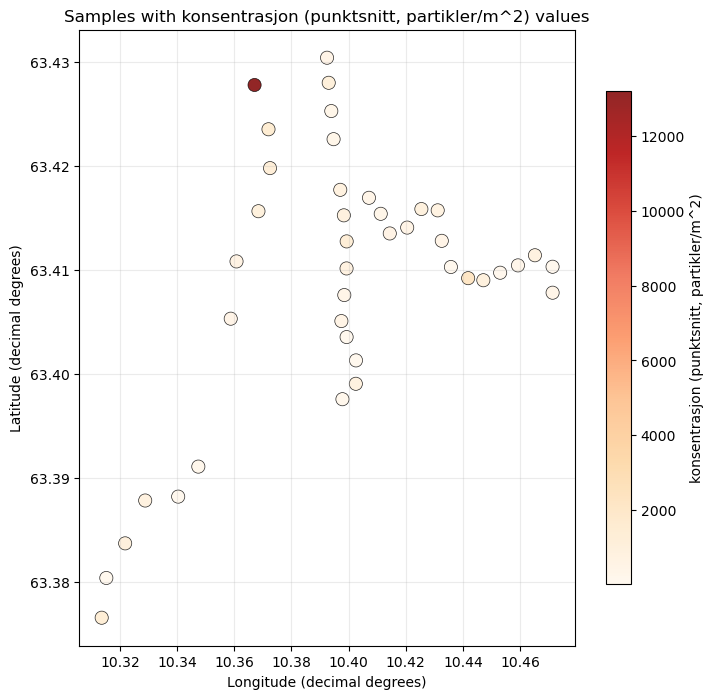

,Prøve ID,"konsentrasjon (punktsnitt, partikler/m^2)"
137,V340,13185.595568
24,V125,2216.066482
134,V337,1495.844875
98,V301,1375.807941
72,V222,1348.107110
131,V334,1246.537396
54,V204,1080.332410
104,V307,1015.697138
128,V331,997.229917
12,V113,941.828255


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

value_col = "konsentrasjon (punktsnitt, partikler/m^2)"

points_with_value_df = veg_enriched_df.copy()
points_with_value_df[value_col] = pd.to_numeric(points_with_value_df[value_col], errors="coerce")
points_with_value_df["x"] = pd.to_numeric(points_with_value_df["x"], errors="coerce")
points_with_value_df["y"] = pd.to_numeric(points_with_value_df["y"], errors="coerce")

points_with_value_df = points_with_value_df.dropna(subset=[value_col, "x", "y"]).copy()
points_with_value_df = points_with_value_df.sort_values(value_col, ascending=False)

print(f"Rows with {value_col} values and coordinates: {len(points_with_value_df)}")
display(points_with_value_df[["Prøve ID", "x", "y", value_col]].head(30))

v401_value_df = veg_enriched_df.loc[
    veg_enriched_df["Prøve ID"].astype(str).str.strip() == "V401",
    ["Prøve ID", "x", "y", value_col],
].copy()
v401_value_df[value_col] = pd.to_numeric(v401_value_df[value_col], errors="coerce")
print("\nV401 value: ")
display(v401_value_df)

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    points_with_value_df["x"],
    points_with_value_df["y"],
    c=points_with_value_df[value_col],
    cmap="OrRd",
    s=90,
    edgecolors="black",
    linewidths=0.5,
    alpha=0.85,
 )

cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
cbar.set_label(value_col)

ax.set_title("Samples with konsentrasjon (punktsnitt, partikler/m^2) values")
ax.set_xlabel("Longitude (decimal degrees)")
ax.set_ylabel("Latitude (decimal degrees)")
ax.grid(alpha=0.25)
plt.show()

points_with_value_df[["Prøve ID", value_col]].head(10)





In [4]:
import pandas as pd

# For 400-500 samples, compute and store konsentrasjon (partikler/m^2) from Antall dekkpartikler / (0.38^2).
radius_m = 0.38
area_m2 = radius_m ** 2

veg_enriched_df = veg_enriched_df.copy()
veg_enriched_df["prove_id_numeric"] = pd.to_numeric(veg_enriched_df["prove_id_numeric"], errors="coerce")
veg_enriched_df["Antall dekkpartikler"] = pd.to_numeric(veg_enriched_df["Antall dekkpartikler"], errors="coerce")
veg_enriched_df["konsentrasjon (partikler/m^2)"] = pd.to_numeric(
    veg_enriched_df["konsentrasjon (partikler/m^2)"],
    errors="coerce",
)

is_500_dataset = veg_enriched_df["prove_id_numeric"] >= 400
has_particle_count = veg_enriched_df["Antall dekkpartikler"].notna()
update_mask = is_500_dataset & has_particle_count

veg_enriched_df.loc[update_mask, "konsentrasjon (partikler/m^2)"] = (
    veg_enriched_df.loc[update_mask, "Antall dekkpartikler"] / area_m2
)

print(f"Area used (0.38^2): {area_m2:.4f} m^2")
print(f"500-series rows with Antall dekkpartikler updated: {int(update_mask.sum())}")

v401_calc = veg_enriched_df.loc[
    veg_enriched_df["Prøve ID"].astype(str).str.strip() == "V401",
    ["Prøve ID", "Antall dekkpartikler", "konsentrasjon (partikler/m^2)"],
]

print("Updated value for V401:")
display(v401_calc)

if not v401_calc.empty:
    print(f"V401 konsentrasjon (partikler/m^2): {v401_calc.iloc[0]['konsentrasjon (partikler/m^2)']:.2f}")

Area used (0.38^2): 0.1444 m^2
500-series rows with Antall dekkpartikler updated: 23
Updated value for V401:


,Prøve ID,Antall dekkpartikler,konsentrasjon (partikler/m^2)
143,V401,136.0,941.828255


V401 konsentrasjon (partikler/m^2): 941.83


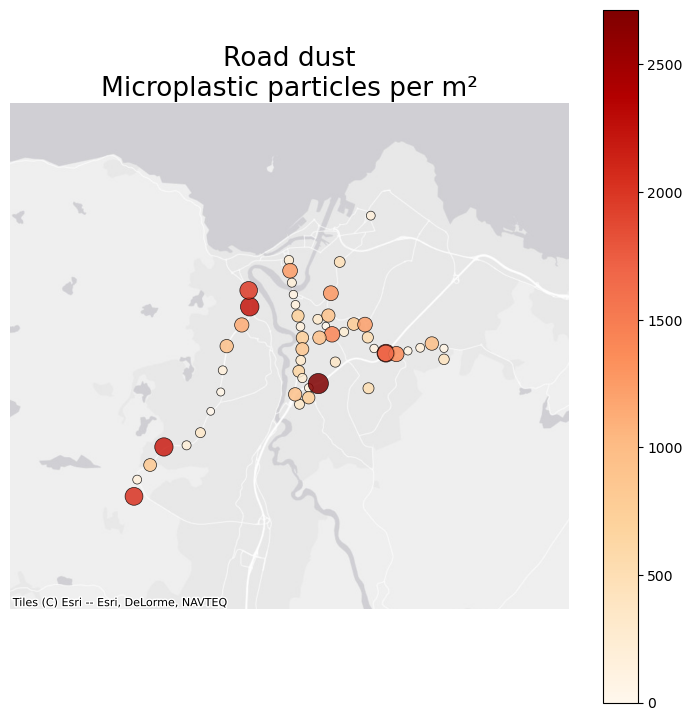

Mapped rows from 100-200-300: 43
Mapped rows from 400-500: 10


,Prøve ID,dataset,konsentrasjon (partikler/m^2),x,y
143,V401,400-500,941.828255,10.407982,63.412745


In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

try:
    import contextily as cx
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "contextily"])
    import contextily as cx

value_col = "konsentrasjon (partikler/m^2)"

veg_map_df = veg_enriched_df.copy()
veg_map_df[value_col] = pd.to_numeric(veg_map_df[value_col], errors="coerce")
veg_map_df["x"] = pd.to_numeric(veg_map_df["x"], errors="coerce")
veg_map_df["y"] = pd.to_numeric(veg_map_df["y"], errors="coerce")
veg_map_df["dataset"] = veg_map_df["prove_id_numeric"].apply(
    lambda value: "400-500" if pd.notna(value) and value >= 400 else "100-200-300"
)

veg_map_df = veg_map_df.dropna(subset=[value_col, "x", "y"]).copy()
veg_map_df = veg_map_df[~veg_map_df["Prøve ID"].astype(str).str.strip().isin(["V340", "V407"])].copy()

veg_map_gdf = gpd.GeoDataFrame(
    veg_map_df,
    geometry=gpd.points_from_xy(veg_map_df["x"], veg_map_df["y"]),
    crs="EPSG:4326",
)
veg_map_webmerc = veg_map_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
veg_map_webmerc.plot(
    ax=ax,
    column=value_col,
    cmap="OrRd",
    legend=True,
    markersize=veg_map_webmerc[value_col] / 15 + 30,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
)

x_min, y_min, x_max, y_max = veg_map_webmerc.total_bounds
x_pad = (x_max - x_min) * 0.40
y_pad = (y_max - y_min) * 0.40
ax.set_xlim(x_min - x_pad, x_max + x_pad)
ax.set_ylim(y_min - y_pad, y_max + y_pad)

cx.add_basemap(ax, source=cx.providers.Esri.WorldGrayCanvas)
ax.set_title("Road dust\nMicroplastic particles per m²", fontsize=19)
ax.set_axis_off()
plt.show()

print(f"Mapped rows from 100-200-300: {(veg_map_df['dataset'] == '100-200-300').sum()}")
print(f"Mapped rows from 400-500: {(veg_map_df['dataset'] == '400-500').sum()}")
display(veg_map_df.loc[veg_map_df["Prøve ID"].astype(str).str.strip() == "V401", ["Prøve ID", "dataset", value_col, "x", "y"]])

In [6]:
from pathlib import Path

output_dir = Path("Maps")
output_dir.mkdir(exist_ok=True)

output_file = output_dir / "Road_particle_couints_map.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"Map exported to: {output_file}")

Map exported to: Maps/Road_particle_couints_map.png
